### TP INF 372 : Analyse de la Consommation Data

| Nom Complet | Matricule |
| :--- | :--- |
| KAMDOM NGUETCHESSI MERVEILLE PRISCA | 23V2060 |
| YOKO AYMERICK JEFFREY | 23U2983 |
| KENNE YEMTSA LOWEL RAYANN | 23U2477 |

---

# Analyse Exploratoire des Données (EDA)

Cette étape consiste à interroger les données pour en extraire des comportements. L'objectif est de vérifier si les variables dont nous disposons (Volume, Statut, Jour) présentent réellement des différences significatives selon la période de la journée.

### Initialisation de l'analyse

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
df = pd.read_csv("../../data/processed/composed_dataset.csv")

## 1. Distribution de la Consommation

### Intuition : La distribution asymétrique
L'usage d'internet suit souvent une loi de puissance : beaucoup de petites sessions (notifications, messages) et quelques sessions très gourmandes (vidéos, téléchargements).
**Pourquoi utiliser l'échelle logarithmique ?** Sans elle, les quelques sessions massives écraseraient visuellement tout le reste du graphique, nous empêchant de voir la distribution réelle des données.

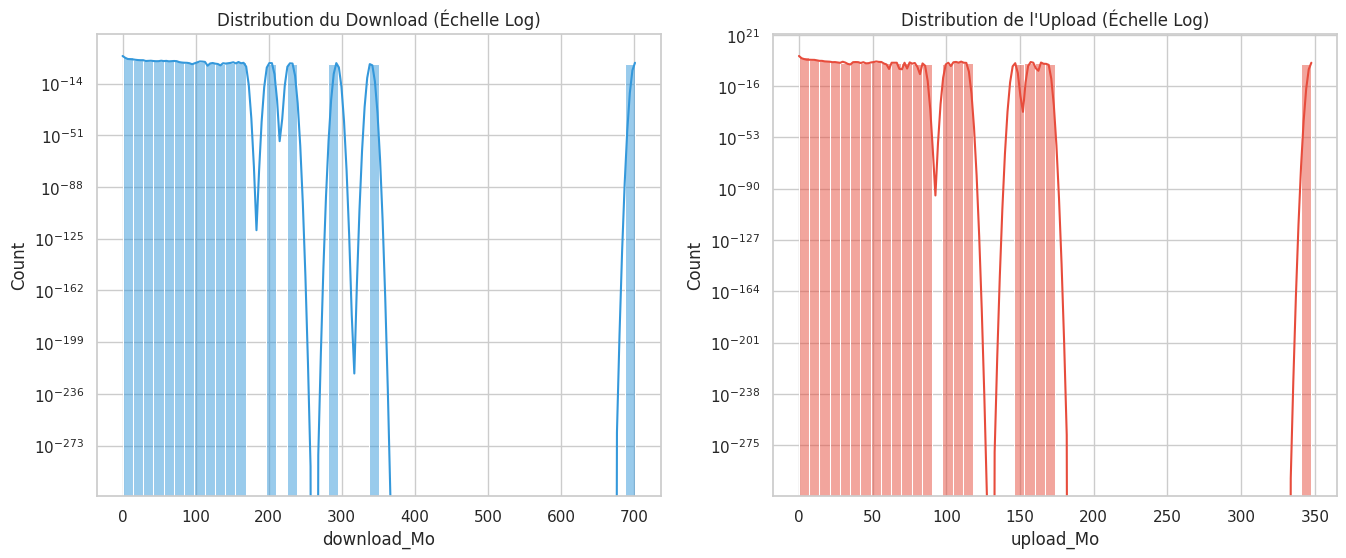

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(df['download_Mo'], bins=50, kde=True, ax=ax[0], color="#3498db")
ax[0].set_title('Distribution du Download (Échelle Log)')
ax[0].set_yscale('log')

sns.histplot(df['upload_Mo'], bins=50, kde=True, ax=ax[1], color="#e74c3c")
ax[1].set_title('Distribution de l\'Upload (Échelle Log)')
ax[1].set_yscale('log')

plt.show()

## 2. Variations par Période de la Journée

### Intuition
Si notre projet de classification doit fonctionner, nous devons observer des différences de moyennes entre les périodes. Si la consommation moyenne était identique à 8h et à 22h, le modèle ne pourrait rien apprendre.
**Observation attendue** : Des pics de consommation le Soir et la Nuit par rapport au Matin.

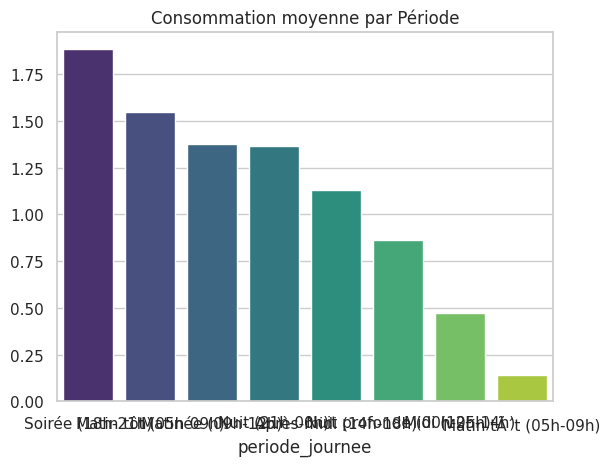

In [3]:
period_stats = df.groupby('periode_journee')['download_Mo'].mean().sort_values(ascending=False)
sns.barplot(x=period_stats.index, y=period_stats.values, palette="viridis", hue=period_stats.index, legend=False)
plt.title('Consommation moyenne par Période')
plt.show()

## 3. Analyse des Corrélations

### Pourquoi faire une matrice de corrélation ?
Cela nous permet d'identifier si certaines variables sont redondantes (ex: `total_Mo` est juste la somme des deux autres) ou si certaines sont très liées à la durée des sessions.

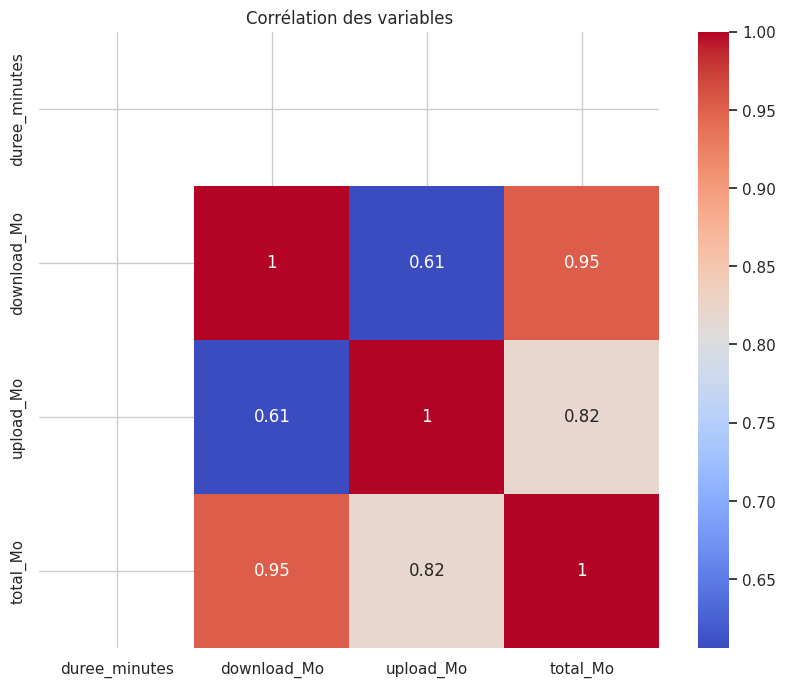

In [4]:
plt.figure(figsize=(10, 8))
numeric_corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(numeric_corr, annot=True, cmap="coolwarm")
plt.title('Corrélation des variables')
plt.show()

## Conclusion du Notebook 02
Nous avons confirmé que les distributions de données sont asymétriques et que des différences existent entre les périodes de la journée. Cependant, ces différences sont subtiles, ce qui justifie l'utilisation de modèles de classification complexes et d'un travail sur les caractéristiques (Feature Engineering) dans les notebooks suivants.